# Arboretti et al. (2021): machine learning for chemical product innovation

## 0. Reproducibility card

**Article.** Arboretti, R., Ceccato, R., Pegoraro, L., Salmaso, L., Housmekerides, C., Spadoni, L., Pierangelo, E., Quaggia, S., Tveit, C., & Vianello, S. (2021). *Machine learning and design of experiments with an application to product innovation in the chemical industry*. Journal of Applied Statistics, 49(10), 2674–2699. [https://doi.org/10.1080/02664763.2021.1907840](https://doi.org/10.1080/02664763.2021.1907840)

| Item | Record |
|---|---|
| Open-access route | [PubMed Central author manuscript, PMCID: PMC9225671](https://pmc.ncbi.nlm.nih.gov/articles/PMC9225671/) |
| Licence / reuse status | Copyright © 2021 Informa UK Limited / Taylor & Francis. PMC provides lawful green open access, but no Creative Commons reuse licence is stated. This notebook records facts, short aggregate transcriptions, and original calculations; it does not redistribute the PDF. |
| Citation snapshot | 30 citing works in [OpenAlex W3147063135](https://openalex.org/W3147063135), retrieved 2026-08-02 |
| Reproduction level | **C — methodological reproduction** |
| Random seed | `20210326` (the online publication date) |
| Core tools | `pydoe`, NumPy, pandas, scikit-learn, Matplotlib |
| Source verification | User-supplied article PDF, 26 pages; SHA-256 `cb41e918efcf444810652fedc14154563bda7fb7a1552cd176a5f0e10c5c76fc` |

**Reproduced exactly:** the published experiment counts, model dimensionality, variance-component tables, reported validation metrics, and Table 4 MAE comparison.  
**Reconstructed, not recovered:** a nine-factor Box–Behnken candidate geometry and a deterministic D-optimal reduction with the paper's 130-to-70 run counts.  
**Unavailable:** chemical identities and ranges, response identities, the executed 70-run matrix, row-level responses, randomization, split seed, source code, and optimizer state. Consequently, no paper coefficient, prediction, importance, or uncertainty interval can be independently recalculated.

> **Practitioner reading guide.** Every case follows the same path: scientific context → evidence and provenance → design reconstruction → design diagnostics → article analysis → publication checks → a clearly labelled teaching extension → practitioner conclusions → reproducibility metadata. **Paper** denotes a published result, **reproduction** a notebook calculation from available evidence, and **teaching analysis** a new demonstration rather than new experimental evidence. Install the shared [`requirements.txt`](requirements.txt); Section 9 records the detailed environment used for this notebook's saved execution.


In [1]:
from __future__ import annotations

import platform
import warnings
from datetime import date
from importlib.metadata import version

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pydoe import bbdesign
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import MinMaxScaler, StandardScaler

SEED = 20210326
rng = np.random.default_rng(SEED)
pd.set_option("display.precision", 3)
plt.style.use("seaborn-v0_8-whitegrid")
COLORS = {"RSM": "#4C78A8", "RF": "#F58518", "ANN": "#54A24B"}

print(f"Python {platform.python_version()} | seed {SEED} | execution date {date.today()}")

Python 3.13.2 | seed 20210326 | execution date 2026-08-02


## 1. Scientific context

The industrial question was whether response-surface methodology (RSM), random forests (RF), or an ensemble of artificial neural networks (ANN) best predicts washing performance during early detergent formulation. Nine confidential chemical components were varied at three coded levels, and three confidential stain-removal responses (`y1`, `y2`, `y3`) were measured as CIELAB reflectance percentages; 100% denotes perfect removal. Washing cycle and water temperature were held fixed.

The experimental unit needs careful wording. A **formulation treatment** was applied in two washing cycles on different machine units. Each cycle contained two fabric samples. Thus, for each response:

- 70 distinct treatments × 2 washing cycles = 140 cycle-level replicates;
- 140 cycles × 2 fabrics = 280 raw observations;
- the paper averaged the two fabrics within a cycle, leaving 140 rows for predictive modelling.

The article writes the nested model as $z_{ijk}=\mu+t_i+w_{ij}+\varepsilon_{ijk}$, where $w_{ij}$ is washing-cycle/machine variation nested within treatment and $\varepsilon_{ijk}$ is fabric-level error. The Box–Behnken design (BBD) avoids simultaneous all-low/all-high corners, which were physically unattractive, while supporting a full quadratic model. Factor identities, ranges, units, run order, and blocking/randomization details remain confidential; only coded geometry can therefore be discussed.

In [2]:
published_counts = pd.Series({
    "factors": 9,
    "reported spherical candidate points": 120,
    "candidate centre points": 10,
    "candidate total": 130,
    "D-optimal treatments": 70,
    "washing cycles per treatment": 2,
    "fabric samples per cycle": 2,
    "cycle-level modelling rows": 140,
    "raw observations per response": 280,
}, name="published count")
published_counts.to_frame()

,published count
factors,9
reported spherical candidate points,120
candidate centre points,10
candidate total,130
D-optimal treatments,70
washing cycles per treatment,2
fabric samples per cycle,2
cycle-level modelling rows,140
raw observations per response,280


## 2. Data provenance and reproduction boundary

The complete paper was read from the supplied PDF and checked against the lawful PMC manuscript. The article does not publish the formulation table or response rows. The aggregate values below are manually transcribed from Tables 1–4 and Figures 9–11, retaining the displayed precision. Assertions guard against transcription drift.

The variance labels follow the paper. `treatment:replicate` describes variation between the replicate washing cycles within formulation; `error` is the fabric-level residual. These are **not** an open substitute for the missing observations.

In [3]:
variance_components = pd.DataFrame([
    ("y1", "total", 89.96, 19.55, 100.00, 4.42, 6.34, 69.72, 280),
    ("y1", "treatment:replicate", 70.00, 14.77, 75.57, 3.84, 5.51, 69.72, 280),
    ("y1", "error", 140.00, 4.77, 24.43, 2.19, 3.13, 69.72, 280),
    ("y2", "total", 139.76, 4.33, 100.00, 2.08, 4.21, 49.48, 280),
    ("y2", "treatment:replicate", 70.00, 1.45, 33.50, 1.20, 2.43, 49.48, 280),
    ("y2", "error", 140.00, 2.88, 66.50, 1.70, 3.43, 49.48, 280),
    ("y3", "total", 138.68, 3.50, 100.00, 1.87, 3.27, 57.16, 280),
    ("y3", "treatment:replicate", 70.00, 1.20, 34.28, 1.09, 1.91, 57.16, 280),
    ("y3", "error", 140.00, 2.30, 65.72, 1.52, 2.65, 57.16, 280),
], columns=["response", "source", "df", "variance", "percent", "sd", "cv_percent", "mean", "N"])

published_mae = pd.DataFrame({
    "RF": [3.624, 1.874, 1.921],
    "ANN": [3.842, 1.974, 1.697],
    "RSM": [4.553, 2.449, 2.376],
    "reported_improvement_percent": [20.40, 23.48, 28.56],
}, index=pd.Index(["y1", "y2", "y3"], name="response"))

published_scores = pd.DataFrame([
    ("y1", "RF", "CV", .687, 3.212, 4.58), ("y1", "RF", "test", .652, 3.624, 5.42),
    ("y1", "ANN", "CV", .754, 2.840, 4.07), ("y1", "ANN", "test", .627, 3.842, 5.74),
    ("y2", "RF", "CV", .936, 2.004, 4.21), ("y2", "RF", "test", .963, 1.874, 3.80),
    ("y2", "ANN", "CV", .961, 1.672, 3.45), ("y2", "ANN", "test", .957, 1.974, 4.04),
    ("y3", "RF", "CV", .854, 1.518, 2.71), ("y3", "RF", "test", .877, 1.921, 3.39),
    ("y3", "ANN", "CV", .836, 1.641, 2.92), ("y3", "ANN", "test", .879, 1.697, 3.01),
], columns=["response", "model", "partition", "correlation", "MAE", "MAPE_percent"])

assert len(variance_components) == 9 and not variance_components.isna().any().any()
assert np.all(variance_components.query("source == 'total'").N == 280)
assert published_mae.shape == (3, 4)
display(variance_components, published_mae, published_scores)

,response,source,df,variance,percent,sd,cv_percent,mean,N
0,y1,total,89.96,19.55,100.00,4.42,6.34,69.72,280
1,y1,treatment:replicate,70.00,14.77,75.57,3.84,5.51,69.72,280
2,y1,error,140.00,4.77,24.43,2.19,3.13,69.72,280
3,y2,total,139.76,4.33,100.00,2.08,4.21,49.48,280
4,y2,treatment:replicate,70.00,1.45,33.50,1.20,2.43,49.48,280
5,y2,error,140.00,2.88,66.50,1.70,3.43,49.48,280
6,y3,total,138.68,3.50,100.00,1.87,3.27,57.16,280
7,y3,treatment:replicate,70.00,1.20,34.28,1.09,1.91,57.16,280
8,y3,error,140.00,2.30,65.72,1.52,2.65,57.16,280


,RF,ANN,RSM,reported_improvement_percent
response,,,,
y1,3.624,3.842,4.553,20.40
y2,1.874,1.974,2.449,23.48
y3,1.921,1.697,2.376,28.56


,response,model,partition,correlation,MAE,MAPE_percent
0,y1,RF,CV,0.687,3.212,4.58
1,y1,RF,test,0.652,3.624,5.42
2,y1,ANN,CV,0.754,2.840,4.07
3,y1,ANN,test,0.627,3.842,5.74
4,y2,RF,CV,0.936,2.004,4.21
5,y2,RF,test,0.963,1.874,3.80
6,y2,ANN,CV,0.961,1.672,3.45
7,y2,ANN,test,0.957,1.974,4.04
8,y3,RF,CV,0.854,1.518,2.71
9,y3,RF,test,0.877,1.921,3.39


## 3. Reconstruct the design

`pydoe.bbdesign(9, center=0)` supplies a standard nine-factor BBD with 144 edge-midpoint rows: each row has exactly two factors at ±1 and seven at zero. The article instead reports 120 “spherical” points plus 10 centres before D-optimal reduction. It does not reveal which 120 points or which D-optimal algorithm were used.

The reconstruction below makes that gap auditable:

1. generate the standard PyDOE geometry;
2. greedily delete 24 non-centre rows with the smallest quadratic-model leverage, retaining 10 centre replicates;
3. continue the same deterministic D-optimal backward deletion from 130 to 70 rows.

Deleting the smallest leverage at each step greedily preserves $\det(X^TX)$ via the matrix determinant lemma. This is a transparent bridge to the reported dimensions, **not the executed industrial design**. Duplicate centres are eligible only in the second reduction; D-optimality naturally retains one because identical rows add little determinant after replication. Physical-unit decoding and randomized-order mapping are impossible without the confidential ranges and run list.

In [4]:
FACTOR_NAMES = [f"x{i}" for i in range(1, 10)]

def quadratic_matrix(points):
    # Intercept, 9 main effects, 9 pure quadratics, and 36 two-factor interactions.
    points = np.asarray(points, dtype=float)
    columns = [np.ones(len(points))]
    columns.extend(points[:, j] for j in range(points.shape[1]))
    columns.extend(points[:, j] ** 2 for j in range(points.shape[1]))
    columns.extend(points[:, i] * points[:, j]
                   for i in range(points.shape[1]) for j in range(i + 1, points.shape[1]))
    return np.column_stack(columns)

def d_optimal_delete(points, target, eligible_indices=None):
    # Greedy backward D-optimal reduction; ties are resolved by original row index.
    points = np.asarray(points, dtype=float)
    keep = list(range(len(points)))
    eligible = set(range(len(points))) if eligible_indices is None else set(eligible_indices)
    while len(keep) > target:
        X = quadratic_matrix(points[keep])
        information_inverse = np.linalg.inv(X.T @ X)
        leverage = np.einsum("ij,jk,ik->i", X, information_inverse, X)
        choices = [(leverage[pos], original, pos)
                   for pos, original in enumerate(keep) if original in eligible]
        if not choices:
            raise ValueError("No eligible row remains for deletion")
        _, _, position = min(choices)
        keep.pop(position)
    return points[keep], np.asarray(keep)

pydoe_edge = np.asarray(bbdesign(9, center=0), dtype=float)
candidate154 = np.vstack([pydoe_edge, np.zeros((10, 9))])
candidate130, kept130 = d_optimal_delete(candidate154, 130, eligible_indices=range(144))
design70, kept70 = d_optimal_delete(candidate130, 70)

assert pydoe_edge.shape == (144, 9)
assert np.all(np.sum(pydoe_edge ** 2, axis=1) == 2)
assert candidate130.shape == (130, 9)
assert (np.sum(np.abs(candidate130), axis=1) == 0).sum() == 10
assert design70.shape == (70, 9)
assert np.linalg.matrix_rank(quadratic_matrix(design70)) == 55

design_frame = pd.DataFrame(design70, columns=FACTOR_NAMES)
design_frame.index = pd.RangeIndex(1, 71, name="reconstructed treatment")
design_frame.head(12)

,x1,x2,x3,x4,x5,x6,x7,x8,x9
reconstructed treatment,,,,,,,,,
1,-1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
5,1.0,0.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0
6,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
7,-1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
8,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
9,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


## 4. Understand the design

A full quadratic model in nine factors has $1+9+9+\binom{9}{2}=55$ coefficients. Seventy distinct settings leave 15 residual degrees of freedom if the model is fit to treatment means. Replicate cycles create pure-error information, but do not add new locations in factor space.

- **Rank** 55 means all quadratic columns are estimable in this reconstruction.
- **Condition number** summarizes numerical sensitivity after coded scaling; lower is better, but it is not an efficiency guarantee.
- **Leverage** identifies settings that carry disproportionate information for the 55-parameter fit.
- **No cube corners** confirms the BBD safety feature: no row has all nine factors simultaneously extreme.
- **Level counts** reveal the sparse three-level projection: each factor is usually zero, so interactions and curvature depend on a limited set of edge points.

These diagnostics apply to the reconstructed geometry. They cannot certify the unreleased industrial matrix.

In [5]:
X70 = quadratic_matrix(design70)
information_inverse = np.linalg.inv(X70.T @ X70)
leverages = np.einsum("ij,jk,ik->i", X70, information_inverse, X70)
sign, logdet = np.linalg.slogdet(X70.T @ X70)
level_counts = pd.DataFrame({
    "low (-1)": (design70 == -1).sum(axis=0),
    "centre (0)": (design70 == 0).sum(axis=0),
    "high (+1)": (design70 == 1).sum(axis=0),
}, index=FACTOR_NAMES)

diagnostics = pd.Series({
    "quadratic columns": X70.shape[1],
    "matrix rank": np.linalg.matrix_rank(X70),
    "residual df from 70 treatment means": len(design70) - np.linalg.matrix_rank(X70),
    "condition number": np.linalg.cond(X70),
    "log det(X'X)": logdet,
    "centre settings retained": int((np.abs(design70).sum(axis=1) == 0).sum()),
    "cube-corner settings": int((np.abs(design70).sum(axis=1) == 9).sum()),
    "maximum leverage": leverages.max(),
    "mean leverage (p/n)": leverages.mean(),
}, name="reconstructed design")
display(diagnostics.to_frame(), level_counts)

,reconstructed design
quadratic columns,55.000
matrix rank,55.000
residual df from 70 treatment means,15.000
condition number,18.149
log det(X'X),62.592
centre settings retained,1.000
cube-corner settings,0.000
maximum leverage,1.000
mean leverage (p/n),0.786


,low (-1),centre (0),high (+1)
x1,7,55,8
x2,8,54,8
x3,8,55,7
x4,7,55,8
x5,7,55,8
x6,7,56,7
x7,8,54,8
x8,8,54,8
x9,8,54,8


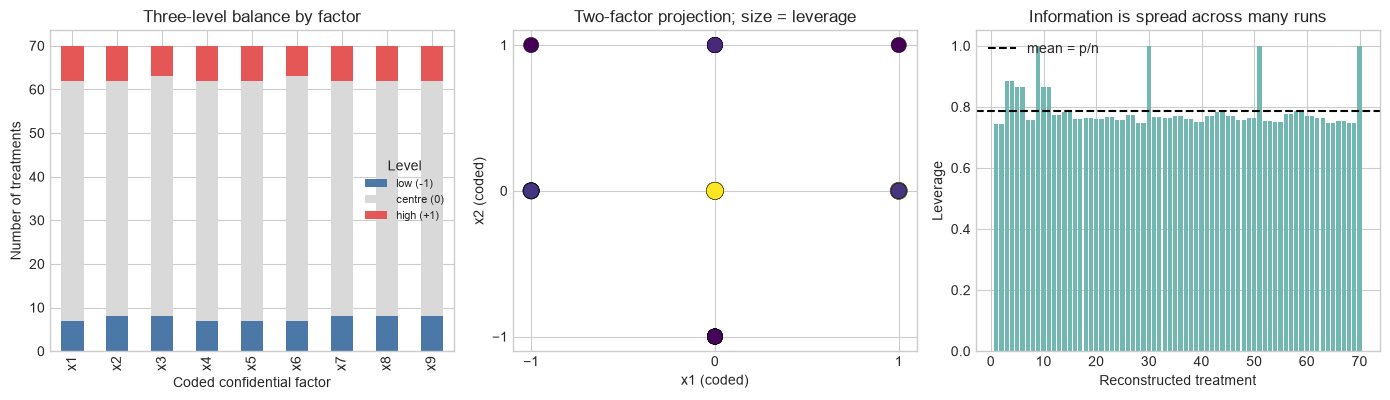

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.1))
level_counts.plot.bar(stacked=True, ax=axes[0], color=["#4C78A8", "#D9D9D9", "#E45756"])
axes[0].set(title="Three-level balance by factor", xlabel="Coded confidential factor", ylabel="Number of treatments")
axes[0].legend(title="Level", fontsize=8)

axes[1].scatter(design70[:, 0], design70[:, 1], s=25 + 130 * leverages,
                c=leverages, cmap="viridis", edgecolor="black", linewidth=.3)
axes[1].set(title="Two-factor projection; size = leverage", xlabel="x1 (coded)", ylabel="x2 (coded)",
            xticks=[-1, 0, 1], yticks=[-1, 0, 1])

axes[2].bar(np.arange(1, 71), leverages, color="#72B7B2")
axes[2].axhline(55 / 70, color="black", linestyle="--", label="mean = p/n")
axes[2].set(title="Information is spread across many runs", xlabel="Reconstructed treatment", ylabel="Leverage")
axes[2].legend()
plt.tight_layout()
plt.show()

The projection repeats many points because the other seven factors change. Bubble size shows that apparently identical `x1`–`x2` locations can carry different multivariate information. This is why a two-dimensional plot alone cannot diagnose a nine-dimensional design.

## 5. Reproduce the article analysis

The paper fit three model families to a random 75/25 split of the 140 cycle averages (105 training, 35 test):

- **RSM:** the full 55-term quadratic model;
- **RF:** 2,000 trees, with split-variable settings selected by fivefold CV and permutation importance; uncertainty combined jackknife-after-bootstrap and infinitesimal-jackknife variances;
- **ANN:** an ensemble of 100 single-hidden-layer logistic networks; 1–10 nodes and weight decay 0–0.5 were selected by fivefold CV; inputs were standardized and responses mapped to [0, 1]. Ensemble 5th/95th percentiles summarized prediction and importance spread.

The reported test MAEs are reproduced below as evidence transcription. RF was best for `y1` and `y2`; ANN was best for `y3`. The percentage improvement compares the best ML score with RSM. These figures cannot be refit without row-level data.

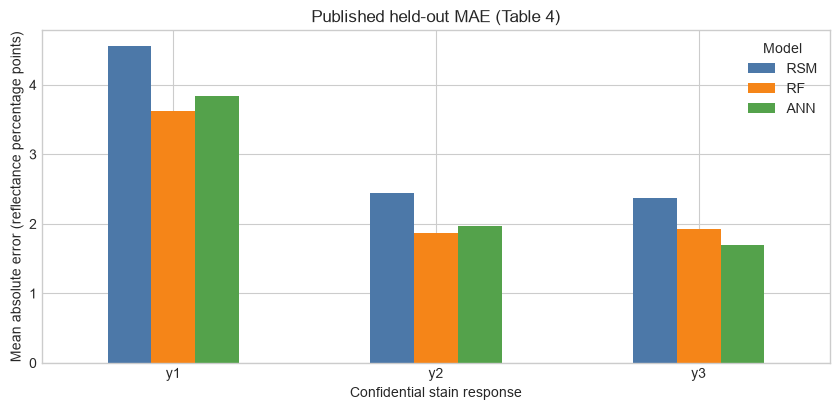

,RF,ANN,RSM,reported_improvement_percent,recalculated_improvement_percent
response,,,,,
y1,3.624,3.842,4.553,20.40,20.404
y2,1.874,1.974,2.449,23.48,23.479
y3,1.921,1.697,2.376,28.56,28.577


In [7]:
best_ml = published_mae[["RF", "ANN"]].min(axis=1)
published_mae["recalculated_improvement_percent"] = 100 * (
    published_mae["RSM"] - best_ml
) / published_mae["RSM"]

ax = published_mae[["RSM", "RF", "ANN"]].plot.bar(
    figsize=(8.5, 4.2), color=[COLORS["RSM"], COLORS["RF"], COLORS["ANN"]]
)
ax.set(title="Published held-out MAE (Table 4)", xlabel="Confidential stain response", ylabel="Mean absolute error (reflectance percentage points)")
ax.legend(title="Model")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

published_mae

The paper's factor rankings also carry scientific information, albeit without recoverable effect sizes. For `y1`, both ML approaches emphasized `x1`, then `x2` and `x4`; for `y2`, `x6` and `x8` dominated; for `y3`, `x1`, `x2`, `x4`, and `x5` were important, with model-dependent ordering. ANN importance intervals crossed zero for most factors except `x1`, `x2`, and `x4`. A predictive rank is not a signed causal effect: correlated polynomial columns, small samples, and model representation can redistribute importance.

## 6. Validate against the paper

“Reproduced” here has two meanings. Counts and arithmetic are independently checked; aggregate tables are verified transcriptions. The final run locations and fitted outputs remain unavailable.

In [8]:
checks = [
    ("candidate total", 130, len(candidate130), 0, "reported count matched; rows reconstructed"),
    ("candidate non-centres", 120, int((np.abs(candidate130).sum(axis=1) > 0).sum()), 0, "reported count matched"),
    ("candidate centres", 10, int((np.abs(candidate130).sum(axis=1) == 0).sum()), 0, "reported count matched"),
    ("optimized treatments", 70, len(design70), 0, "budget matched; locations unavailable"),
    ("cycle-level rows", 140, len(design70) * 2, 0, "replication arithmetic"),
    ("raw observations/response", 280, len(design70) * 2 * 2, 0, "sampling hierarchy arithmetic"),
    ("quadratic coefficients", 55, X70.shape[1], 0, "1 + 9 + 9 + 36"),
]
for response in published_mae.index:
    checks.append((f"{response} ML improvement (%)",
                   published_mae.loc[response, "reported_improvement_percent"],
                   published_mae.loc[response, "recalculated_improvement_percent"],
                   .03, "recalculated from displayed MAEs; rounding expected"))

validation = pd.DataFrame(checks, columns=["target", "published", "notebook", "tolerance", "explanation"])
validation["absolute difference"] = (validation["notebook"] - validation["published"]).abs()
validation["relative difference (%)"] = np.where(
    validation["published"] != 0,
    100 * validation["absolute difference"] / validation["published"],
    np.nan,
)
validation["within tolerance"] = validation["absolute difference"] <= validation["tolerance"]
assert validation["within tolerance"].all()
validation[["target", "published", "notebook", "absolute difference", "relative difference (%)", "tolerance", "within tolerance", "explanation"]]

,target,published,notebook,absolute difference,relative difference (%),tolerance,within tolerance,explanation
0,candidate total,130.00,130.000,0.000,0.000,0.00,True,reported count matched; rows reconstructed
1,candidate non-centres,120.00,120.000,0.000,0.000,0.00,True,reported count matched
2,candidate centres,10.00,10.000,0.000,0.000,0.00,True,reported count matched
3,optimized treatments,70.00,70.000,0.000,0.000,0.00,True,budget matched; locations unavailable
4,cycle-level rows,140.00,140.000,0.000,0.000,0.00,True,replication arithmetic
5,raw observations/response,280.00,280.000,0.000,0.000,0.00,True,sampling hierarchy arithmetic
6,quadratic coefficients,55.00,55.000,0.000,0.000,0.00,True,1 + 9 + 9 + 36
7,y1 ML improvement (%),20.40,20.404,0.004,0.020,0.03,True,recalculated from displayed MAEs; rounding exp...
8,y2 ML improvement (%),23.48,23.479,0.001,0.004,0.03,True,recalculated from displayed MAEs; rounding exp...
9,y3 ML improvement (%),28.56,28.577,0.017,0.061,0.03,True,recalculated from displayed MAEs; rounding exp...


## 7. Go beyond the paper

### 7.1 The validation issue hidden by a random row split

The article randomly split the 140 cycle rows. Because two rows share every treatment setting, such a split usually places one replicate of a formulation in training and the other in testing. The model then predicts a location it has already seen, which measures **repeatability at known treatments**, not generalization to a new formulation. The paper notes that test observations for treatments 32 and 35 lacked corresponding training instances, confirming that most test settings were represented in training.

The article's score is valid for its stated split, but practitioners must align validation with deployment:

- use a row split if the future task is another cycle at an already-tested formulation;
- group by treatment if the future task is an untested formulation.

### 7.2 A replicate-aware synthetic demonstration

The missing observations cannot be invented. Instead, this explicitly synthetic benchmark uses the reconstructed 70 treatments, two cycles per treatment, and the published `y2` mean/noise variances. Its known response surface makes `x6` and `x8` dominant, consistent with the article only as a teaching choice—not as recovered evidence. Fabric-level readings are generated then averaged exactly as described in the paper.

The comparison repeats both split strategies over 16 fixed seeds. RSM, RF, and a small ANN ensemble receive identical partitions and preprocessing. This is deliberately restrained; no hyperparameter search is used.

In [9]:
def synthetic_y2_treatment_mean(points):
    x6, x8 = points[:, 5], points[:, 7]
    raw = (2.1 * x6 - 1.8 * x8 + 1.0 * x6 * x8 + 0.75 * x6 ** 2
           - 0.55 * x8 ** 2 + 0.35 * points[:, 1] * x6)
    return 49.48 + 4.8 * (raw - raw.mean()) / raw.std(ddof=0)

truth70 = synthetic_y2_treatment_mean(design70)
synthetic_rows = []
synthetic_rng = np.random.default_rng(SEED + 1)
for treatment, (setting, mean_value) in enumerate(zip(design70, truth70), start=1):
    for cycle in (1, 2):
        cycle_effect = synthetic_rng.normal(0, np.sqrt(1.45))
        fabric_errors = synthetic_rng.normal(0, np.sqrt(2.88), size=2)
        fabric_values = mean_value + cycle_effect + fabric_errors
        synthetic_rows.append({
            "treatment": treatment,
            "cycle": cycle,
            **dict(zip(FACTOR_NAMES, setting)),
            "fabric_1": fabric_values[0],
            "fabric_2": fabric_values[1],
            "y2_cycle_mean": fabric_values.mean(),
            "known_noiseless_mean": mean_value,
        })
synthetic = pd.DataFrame(synthetic_rows)

assert synthetic.shape == (140, 15)
assert synthetic.groupby("treatment").size().eq(2).all()
assert np.allclose(synthetic["y2_cycle_mean"], synthetic[["fabric_1", "fabric_2"]].mean(axis=1))
synthetic.head()

,treatment,cycle,x1,x2,x3,x4,x5,x6,x7,x8,x9,fabric_1,fabric_2,y2_cycle_mean,known_noiseless_mean
0,1,1,-1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,49.009,45.017,47.013,49.389
1,1,2,-1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,51.040,52.211,51.626,49.389
2,2,1,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,54.256,50.250,52.253,49.389
3,2,2,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,45.468,49.553,47.510,49.389
4,3,1,-1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,50.870,52.241,51.555,49.389


In [10]:
def fit_predict_rsm(X_train, y_train, X_test):
    Q_train = quadratic_matrix(X_train)
    coefficients = np.linalg.lstsq(Q_train, y_train, rcond=None)[0]
    return quadratic_matrix(X_test) @ coefficients, np.linalg.matrix_rank(Q_train)

def fit_predict_ann_ensemble(X_train, y_train, X_test, seed, members=6):
    x_scaler = StandardScaler().fit(X_train)
    y_scaler = MinMaxScaler().fit(np.asarray(y_train).reshape(-1, 1))
    Xs = x_scaler.transform(X_train)
    ys = y_scaler.transform(np.asarray(y_train).reshape(-1, 1)).ravel()
    predictions = []
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        for member in range(members):
            model = MLPRegressor(
                hidden_layer_sizes=(6,), activation="logistic", alpha=.02,
                solver="lbfgs", max_iter=1000, random_state=seed + member,
            ).fit(Xs, ys)
            scaled = model.predict(x_scaler.transform(X_test))
            predictions.append(y_scaler.inverse_transform(scaled[:, None]).ravel())
    return np.asarray(predictions)

def evaluate_partition(train_idx, test_idx, strategy, split_id):
    X = synthetic[FACTOR_NAMES].to_numpy()
    y = synthetic["y2_cycle_mean"].to_numpy()
    groups = synthetic["treatment"].to_numpy()
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    rsm_prediction, rank = fit_predict_rsm(X_train, y_train, X_test)
    rf = RandomForestRegressor(
        n_estimators=300, max_features="sqrt", min_samples_leaf=2,
        random_state=SEED + split_id, n_jobs=1,
    ).fit(X_train, y_train)
    ann_members = fit_predict_ann_ensemble(X_train, y_train, X_test, SEED + 1000 + split_id)
    overlap = np.isin(groups[test_idx], groups[train_idx]).mean()
    return [
        (strategy, split_id, "RSM", mean_absolute_error(y_test, rsm_prediction), overlap, rank),
        (strategy, split_id, "RF", mean_absolute_error(y_test, rf.predict(X_test)), overlap, rank),
        (strategy, split_id, "ANN", mean_absolute_error(y_test, ann_members.mean(axis=0)), overlap, rank),
    ]

records = []
all_idx = np.arange(len(synthetic))
groups = synthetic["treatment"].to_numpy()
for split_id in range(16):
    row_train, row_test = train_test_split(all_idx, test_size=.25, random_state=SEED + split_id)
    grouped = GroupShuffleSplit(n_splits=1, test_size=.25, random_state=SEED + split_id)
    group_train, group_test = next(grouped.split(all_idx, groups=groups))
    records.extend(evaluate_partition(row_train, row_test, "row-wise", split_id))
    records.extend(evaluate_partition(group_train, group_test, "grouped by treatment", split_id))

benchmark = pd.DataFrame(records, columns=["validation", "split", "model", "MAE", "test treatment overlap", "RSM training rank"])
benchmark_summary = benchmark.groupby(["validation", "model"]).agg(
    median_MAE=("MAE", "median"),
    q10_MAE=("MAE", lambda x: x.quantile(.1)),
    q90_MAE=("MAE", lambda x: x.quantile(.9)),
    mean_test_overlap=("test treatment overlap", "mean"),
    median_RSM_rank=("RSM training rank", "median"),
)
benchmark_summary

median_MAE  q10_MAE  q90_MAE  mean_test_overlap  \
validation           model                                                    
grouped by treatment ANN         1.737    1.542    2.054              0.000   
                     RF          1.896    1.622    2.194              0.000   
                     RSM         3.850    2.753    6.200              0.000   
row-wise             ANN         1.978    1.756    2.150              0.739   
                     RF          1.925    1.723    2.156              0.739   
                     RSM         2.276    1.940    2.640              0.739   

                            median_RSM_rank  
validation           model                   
grouped by treatment ANN               51.0  
                     RF                51.0  
                     RSM               51.0  
row-wise             ANN               55.0  
                     RF                55.0  
                     RSM               55.0

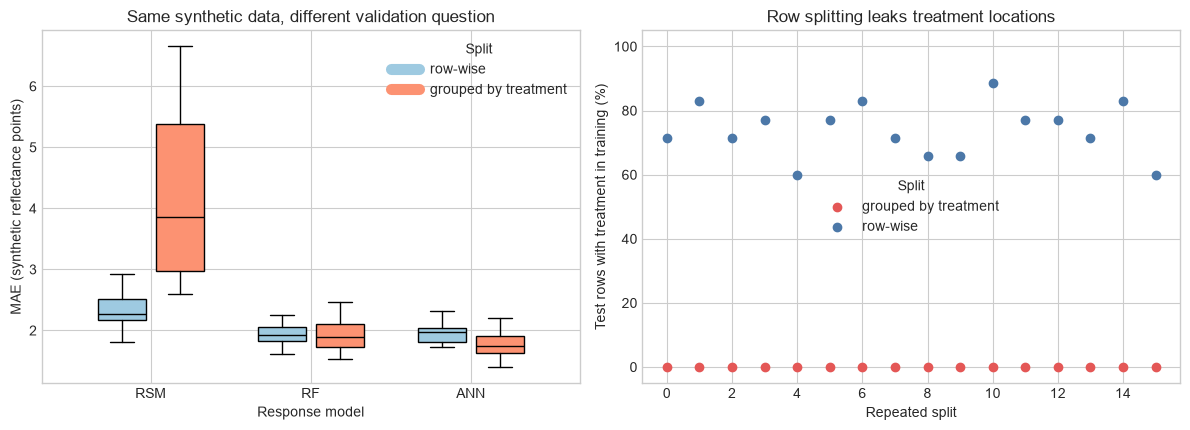

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
positions = np.arange(3)
for offset, strategy in zip([-.18, .18], ["row-wise", "grouped by treatment"]):
    values = [benchmark.query("validation == @strategy and model == @model").MAE.values
              for model in ["RSM", "RF", "ANN"]]
    bp = axes[0].boxplot(values, positions=positions + offset, widths=.3, patch_artist=True,
                         showfliers=False, medianprops={"color": "black"})
    color = "#9ECAE1" if strategy == "row-wise" else "#FC9272"
    for patch in bp["boxes"]:
        patch.set_facecolor(color)
    axes[0].plot([], [], color=color, linewidth=8, label=strategy)
axes[0].set(title="Same synthetic data, different validation question",
            xlabel="Response model", ylabel="MAE (synthetic reflectance points)",
            xticks=positions, xticklabels=["RSM", "RF", "ANN"])
axes[0].legend(title="Split")

overlap_by_split = benchmark.drop_duplicates(["validation", "split"])
for strategy, group in overlap_by_split.groupby("validation"):
    axes[1].scatter(group["split"], 100 * group["test treatment overlap"], label=strategy,
                    color="#4C78A8" if strategy == "row-wise" else "#E45756")
axes[1].set(title="Row splitting leaks treatment locations", xlabel="Repeated split", ylabel="Test rows with treatment in training (%)", ylim=(-5, 105))
axes[1].legend(title="Split")
plt.tight_layout()
plt.show()

The grouped split is the credible test for a new formulation: treatment overlap is exactly zero. It also exposes less geometric support. Here the penalty is dramatic for RSM; the RF and ANN medians need not be worse because the two strategies hold out different treatment sets. That is itself a warning not to diagnose leakage from one score alone. A row-wise score *can* look better because replicate cycles share the same nine-factor coordinates, but it answers a different question. Notice another design constraint: a grouped 75% training sample contains only about 52 distinct settings, fewer than the 55 quadratic coefficients, so the full RSM is rank-deficient. NumPy returns a minimum-norm fit, but the model is not uniquely identified. Repeating measurements improves precision; it does not create new geometric support.

### Are feature ranks and ANN uncertainty stable?

One grouped holdout is used only to demonstrate diagnostics. Permutation importance asks how much held-out MAE worsens after shuffling one factor. The ANN interval is the 5th–95th percentile across 24 small networks, mirroring the paper's ensemble idea at a smaller teaching scale. It measures model-to-model spread, **not** a calibrated prediction interval and not the paper's result.

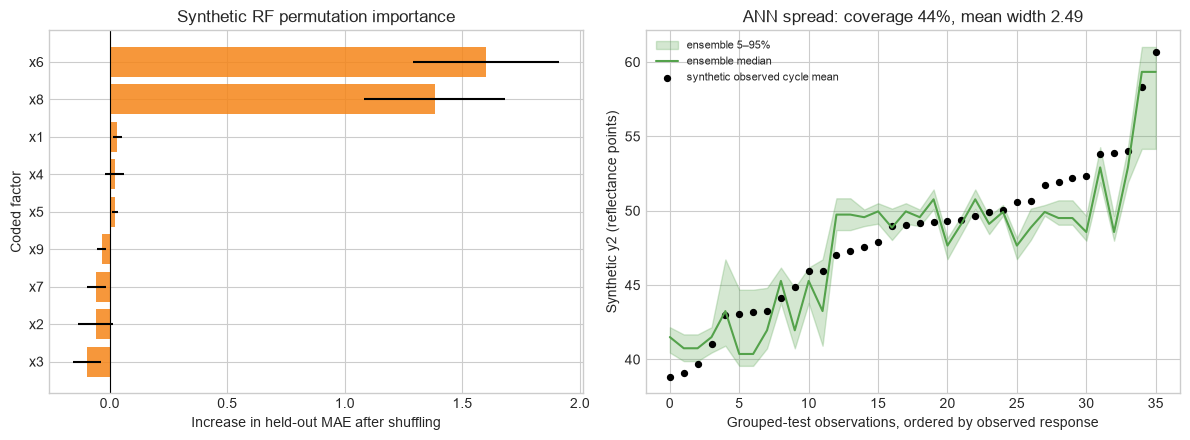

,factor,mean MAE increase,sd
0,x6,1.600,0.312
1,x8,1.383,0.299
2,x1,0.033,0.020
3,x4,0.022,0.040
4,x5,0.022,0.013
5,x9,-0.033,0.019
6,x7,-0.056,0.039
7,x2,-0.059,0.074
8,x3,-0.095,0.060


In [12]:
X_all = synthetic[FACTOR_NAMES].to_numpy()
y_all = synthetic["y2_cycle_mean"].to_numpy()
demo_train, demo_test = next(GroupShuffleSplit(n_splits=1, test_size=.25, random_state=SEED + 99).split(X_all, groups=groups))

demo_rf = RandomForestRegressor(
    n_estimators=1000, max_features="sqrt", min_samples_leaf=2,
    random_state=SEED + 99, n_jobs=1,
).fit(X_all[demo_train], y_all[demo_train])
importance = permutation_importance(
    demo_rf, X_all[demo_test], y_all[demo_test], scoring="neg_mean_absolute_error",
    n_repeats=40, random_state=SEED + 99,
)
importance_frame = pd.DataFrame({
    "factor": FACTOR_NAMES,
    "mean MAE increase": importance.importances_mean,
    "sd": importance.importances_std,
}).sort_values("mean MAE increase")

ann_demo = fit_predict_ann_ensemble(
    X_all[demo_train], y_all[demo_train], X_all[demo_test], SEED + 5000, members=24
)
ann_lower, ann_centre, ann_upper = np.percentile(ann_demo, [5, 50, 95], axis=0)
ann_coverage = np.mean((y_all[demo_test] >= ann_lower) & (y_all[demo_test] <= ann_upper))
ann_width = np.mean(ann_upper - ann_lower)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].barh(importance_frame["factor"], importance_frame["mean MAE increase"],
             xerr=importance_frame["sd"], color="#F58518", alpha=.85)
axes[0].axvline(0, color="black", linewidth=.8)
axes[0].set(title="Synthetic RF permutation importance", xlabel="Increase in held-out MAE after shuffling", ylabel="Coded factor")

order = np.argsort(y_all[demo_test])
xx = np.arange(len(order))
axes[1].fill_between(xx, ann_lower[order], ann_upper[order], color="#54A24B", alpha=.25, label="ensemble 5–95%")
axes[1].plot(xx, ann_centre[order], color="#54A24B", label="ensemble median")
axes[1].scatter(xx, y_all[demo_test][order], color="black", s=18, label="synthetic observed cycle mean")
axes[1].set(title=f"ANN spread: coverage {ann_coverage:.0%}, mean width {ann_width:.2f}",
            xlabel="Grouped-test observations, ordered by observed response", ylabel="Synthetic y2 (reflectance points)")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

display(importance_frame.sort_values("mean MAE increase", ascending=False).reset_index(drop=True))

The known synthetic signal makes `x6` and `x8` rise to the top, but small or negative held-out permutation scores for weak factors show that importance is validation-sample dependent. The ANN band can miss observations despite using 5th/95th ensemble percentiles: ensemble disagreement omits irreducible cycle/fabric noise and is therefore not automatically a 90% predictive interval.

## 8. Practitioner conclusions

- **What DoE made possible.** A 70-treatment BBD-derived plan explored nine formulation components without dangerous cube corners and was intended to support all 55 quadratic terms. Replicate cycles and fabrics separately exposed process and measurement variability.
- **What one-factor-at-a-time would miss.** Two-factor interactions, joint curvature, and predictions away from coordinate axes. It would also spend runs inefficiently when nine components interact.
- **What is supported versus merely fitted.** The paper's complete 70-setting matrix may support its full quadratic, but the public record cannot verify rank or conditioning. In grouped 75/25 validation, fewer than 55 unique training settings cannot uniquely estimate a 55-term RSM even when there are 104 cycle rows.
- **Where prediction is trustworthy.** Most credible near sampled BBD edge/centre geometry and for the deployment target represented by the validation split. A replicate-contaminated row split addresses known formulations; grouped validation addresses new formulations.
- **Design limitations.** Confidential ranges prevent distance, physical feasibility, and extrapolation checks. BBD omits cube corners, so predictions there are extrapolations. Replication improves pure-error estimation but not coverage.
- **Model limitations.** Lower MAE does not make RF/ANN effects causal or scientifically interpretable. RSM can be biased by nonquadratic structure; flexible ML can overfit sparse geometry; variable importance and ensemble intervals can be unstable.
- **Mistakes to avoid.** Do not count repeated measurements as new factor-space locations, randomly split replicate rows when the goal is a new treatment, infer a reuse licence from free access, or present this reconstructed matrix and synthetic response as company data.

The paper is coherent with Awesome DoE precisely because it exposes the boundary between an efficient experimental plan and a predictive model: ML changes how responses are fitted, but it cannot manufacture experimental support that the design did not collect.

## 9. Reproducibility metadata

The final cell records the executed environment. All random operations use fixed seeds. The notebook has no dependency on the supplied PDF at run time and stores no confidential or copyrighted source data.

In [13]:
metadata = pd.Series({
    "execution_date": str(date.today()),
    "python": platform.python_version(),
    "pydoe": version("pydoe"),
    "numpy": version("numpy"),
    "pandas": version("pandas"),
    "scikit-learn": version("scikit-learn"),
    "matplotlib": version("matplotlib"),
    "seed": SEED,
    "article_pdf_sha256": "cb41e918efcf444810652fedc14154563bda7fb7a1552cd176a5f0e10c5c76fc",
    "reproduction_level": "C — methodological reproduction",
})
assert validation["within tolerance"].all()
assert benchmark.groupby("validation")["test treatment overlap"].mean()["grouped by treatment"] == 0
metadata.to_frame("value")

,value
execution_date,2026-08-02
python,3.13.2
pydoe,1.3.1.dev11+geca1a2598
numpy,2.3.4
pandas,3.0.0
scikit-learn,1.9.0
matplotlib,3.11.1
seed,20210326
article_pdf_sha256,cb41e918efcf444810652fedc14154563bda7fb7a1552c...
reproduction_level,C — methodological reproduction
